# Hierarchical Multi-Agent Travel Planner & Budget Auditor
This notebook demonstrates a hierarchical multi-agent architecture using **pure LangChain** and **OpenAI**. 

In this setup, a **Main Agent** (Travel Concierge) acts as an orchestrator. It receives a complex user request, decomposes it into specific tasks, and delegates those tasks to specialized **Subagents** (Hotel Finder, Culinary Guide, and Budget Auditor) which are exposed as tools.

### System Architecture:
```
                     ┌──────────────────┐
                     │   User Request   │
                     └────────┬─────────┘
                              │
                              ▼
                     ┌──────────────────┐
                     │    Main Agent    │
                     │ (Travel Concierge)│
                     └────────┬─────────┘
                              │
         ┌────────────────────┼────────────────────┐
         │                    │                    │
         ▼                    ▼                    ▼
┌──────────────────┐ ┌──────────────────┐ ┌──────────────────┐
│    Subagent A    │ │    Subagent B    │ │    Subagent C    │
│  (Hotel Finder)  │ │ (Culinary Guide) │ │ (Budget Auditor) │
└──────────────────┘ └──────────────────┘ └──────────────────┘
```

## 1. Setup & Environment Variables
Install the required libraries and set up your OpenAI API key.

In [2]:
# Install dependencies if needed:
# !pip install langchain langchain-openai langchain-core pydantic

import os
from getpass import getpass

# Set up your GEMINI API key
if "GEMINI_API_KEY" not in os.environ:
    os.environ["GEMINI_API_KEY"] = getpass("Enter your GEMINI API Key: ")

## 2. Local Databases & Subagent Tools
We define local dictionaries containing mock hotel and restaurant information, along with Python helper functions. These helper functions are decorated with `@tool` so they can be parsed by LangChain as valid agent tools.

In [3]:
from langchain.tools import tool

# Mock databases
HOTEL_DB = {
    "tokyo": [
        {"name": "Shibuya Capsule Inn", "price_per_night": 60.0, "details": "Budget friendly capsule hotel in the heart of Shibuya."},
        {"name": "Hotel Sunroute Plaza Shinjuku", "price_per_night": 140.0, "details": "Mid-range business hotel close to Shinjuku station."},
        {"name": "Park Hyatt Tokyo", "price_per_night": 750.0, "details": "Luxury hotel with stunning city views."}
    ],
    "kyoto": [
        {"name": "Kyoto Guesthouse Hachi", "price_per_night": 45.0, "details": "Traditional wooden townhouse style hostel."},
        {"name": "The Thousand Kyoto", "price_per_night": 180.0, "details": "Sleek, modern eco-friendly hotel near Kyoto station."}
    ]
}

RESTAURANT_DB = {
    "tokyo": [
        {"name": "Ichiran Ramen Shibuya", "cost": 15.0, "type": "ramen", "description": "Classic tonkotsu ramen with individual dining booths."},
        {"name": "Sukiyabashi Jiro", "cost": 350.0, "type": "sushi", "description": "World-famous luxury sushi dining experience."},
        {"name": "Sushizanmai Shinjuku", "cost": 40.0, "type": "sushi", "description": "High-quality, affordable sushi chain open 24/7."}
    ],
    "kyoto": [
        {"name": "Gyoza Hohei", "cost": 12.0, "type": "gyoza", "description": "Popular spot in Gion famous for ginger gyoza."},
        {"name": "Kyoto Kitcho Arashiyama", "cost": 400.0, "type": "kaiseki", "description": "Ultra-premium traditional multi-course dining."}
    ]
}

# Define subagent tools
@tool
def search_hotels(city: str, max_price: float) -> str:
    """Searches for hotels in a given city under a maximum price per night."""
    city_key = city.lower().strip()
    if city_key not in HOTEL_DB:
        return f"No hotel records found for city: '{city}'."
    
    results = [h for h in HOTEL_DB[city_key] if h["price_per_night"] <= max_price]
    if not results:
        return f"No hotels found in {city} under ${max_price}/night."
    
    output = f"Available Hotels in {city} (Max ${max_price}/night):\n"
    for h in results:
        output += f"- {h['name']}: ${h['price_per_night']}/night. Details: {h['details']}\n"
    return output

@tool
def search_restaurants(city: str, preference: str) -> str:
    """Searches for restaurants in a city based on a preference (e.g. 'sushi', 'ramen')."""
    city_key = city.lower().strip()
    pref_key = preference.lower().strip()
    if city_key not in RESTAURANT_DB:
        return f"No restaurant records found for city: '{city}'."
    
    results = [r for r in RESTAURANT_DB[city_key] if pref_key in r["type"] or pref_key in r["description"].lower()]
    if not results:
        return f"No restaurants found in {city} matching '{preference}'."
    
    output = f"Recommended Dining in {city} for '{preference}':\n"
    for r in results:
        output += f"- {r['name']} (Estimated cost: ${r['cost']}). Description: {r['description']}\n"
    return output

@tool
def audit_expenses(hotel_cost: float, food_cost: float, budget_limit: float) -> str:
    """Performs budget audit calculations including taxes/fees, and compares against budget limits."""
    # Assume hotel has 10% tax, food has 8% tax
    taxed_hotel = hotel_cost * 1.10
    taxed_food = food_cost * 1.08
    total_cost = taxed_hotel + taxed_food
    
    discrepancy = budget_limit - total_cost
    status = "APPROVED" if discrepancy >= 0 else "REJECTED (OVER BUDGET)"
    
    output = f"--- Financial Audit Report ---\n"
    output += f"Base Hotel Cost: ${hotel_cost:.2f} | With Tax (10%): ${taxed_hotel:.2f}\n"
    output += f"Base Food Cost: ${food_cost:.2f} | With Tax (8%): ${taxed_food:.2f}\n"
    output += f"Total Estimated Cost: ${total_cost:.2f}\n"
    output += f"Budget Limit: ${budget_limit:.2f}\n"
    output += f"Difference: ${discrepancy:.2f}\n"
    output += f"Status: {status}\n"
    return output

## 3. Define Subagent Helper & Instantiation
We define a helper function `create_subagent` to initialize subagent runners, then instantiate our three specialized Subagents (Hotel Finder, Culinary Guide, and Budget Auditor) with their respective tools and prompts.

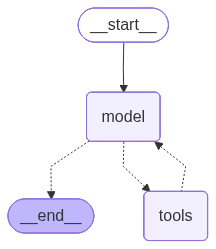

In [4]:
from langchain.agents import create_agent
from langchain_google_genai import ChatGoogleGenerativeAI

# Initialize LLM (using temperature 0 for predictable calculations)
llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite", temperature=0)

# Create specialized subagents using create_agent from LangChain
hotel_finder_agent = create_agent(
    model=llm,
    tools=[search_hotels],
    system_prompt=(
        "You are a specialized Hotel Finder Agent. Your job is to find suitable hotel recommendations "
        "using the search_hotels tool. Always format your output cleanly as a list of options with prices."
    )
)
hotel_finder_agent


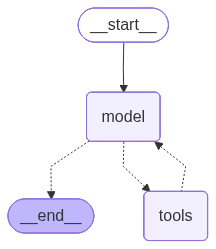

In [5]:
culinary_guide_agent = create_agent(
    model=llm,
    tools=[search_restaurants],
    system_prompt=(
        "You are a specialized Culinary Guide Agent. Your job is to recommend restaurants and food "
        "experiences using the search_restaurants tool. Format your output as a list of recommended spots."
    )
)
culinary_guide_agent


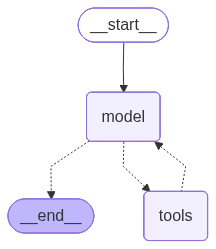

In [6]:
budget_auditor_agent = create_agent(
    model=llm,
    tools=[audit_expenses],
    system_prompt=(
        "You are a specialized Budget Auditor Agent. Your job is to perform financial calculations "
        "and audit the expenses against the user's budget limit. Always output the complete audit report."
    )
)
budget_auditor_agent

## 4. Wrapping Subagents as Tools
To allow the Main Agent to delegate tasks to the Subagents, we wrap each subagent's invocation pipeline in a standard LangChain `Tool`. This exposes them as callable functions with descriptive strings that the Main Agent's planner can read.

In [8]:
from langchain.tools import tool
from langchain_core.runnables import RunnableConfig

# Wrap each subagent as a tool so the main agent can call them, passing config for callback propagation
@tool("Hotel_Finder_Agent", description="Use this tool to find lodging/hotel options in a specific city. Input should be a clear query like 'find hotels in Tokyo under $150 per night'.")
def call_hotel_agent(query: str, config: RunnableConfig) -> str:
    """Call the hotel finder subagent."""
    result = hotel_finder_agent.invoke({"messages": [{"role": "user", "content": query}]}, config)
    return result["messages"][-1].content

@tool("Culinary_Guide_Agent", description="Use this tool to find food experiences and restaurants in a city. Input should be a query like 'find authentic sushi and ramen spots in Tokyo'.")
def call_culinary_agent(query: str, config: RunnableConfig) -> str:
    """Call the culinary guide subagent."""
    result = culinary_guide_agent.invoke({"messages": [{"role": "user", "content": query}]}, config)
    return result["messages"][-1].content

@tool("Budget_Auditor_Agent", description="Use this tool to calculate total costs and check if they fit within budget limits. Input should contain hotel cost, food cost, and budget ceiling.")
def call_budget_agent(query: str, config: RunnableConfig) -> str:
    """Call the budget auditor subagent."""
    result = budget_auditor_agent.invoke({"messages": [{"role": "user", "content": query}]}, config)
    return result["messages"][-1].content

# List of tools for the main agent
main_agent_tools = [call_hotel_agent, call_culinary_agent, call_budget_agent]

## 5. Main Agent Setup
Now we create the Main Agent (Travel Concierge). It is equipped with the three subagent tools. We provide a detailed system prompt defining how it should decompose user queries, invoke the subagents in order, and compile the final summary.

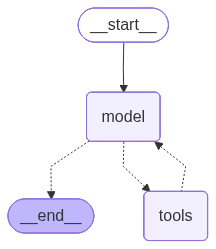

In [9]:
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver

# Create the Main Agent (Travel Concierge) using LangChain's create_agent
main_agent_prompt = (
    "You are the Travel Concierge, a main coordinator agent. "
    "Your goal is to plan a trip for the user by delegating specific tasks to specialized subagents. "
    "\n\n"
    "Available subagents:\n"
    "1. Hotel_Finder_Agent: Find lodging options matching budget and city\n"
    "2. Culinary_Guide_Agent: Find restaurant and dining options\n"
    "3. Budget_Auditor_Agent: Verify if costs fit the budget ceiling\n"
    "\n\n"
    "Step-by-step workflow:\n"
    "a. Call the Hotel Finder to get hotel recommendations. Select one hotel and note its nightly cost (calculate total for the number of nights).\n"
    "b. Call the Culinary Guide to get restaurant recommendations and note their estimated costs.\n"
    "c. Call the Budget Auditor with the total hotel cost, total food cost, and user's budget limit to check if it fits.\n"
    "d. Synthesize all results into a comprehensive response for the user, detailing the hotel, restaurants, and budget status.\n"
    "Always run the audit step before finishing your response."
)

# Create persistent SQLite checkpointer database connection
conn = sqlite3.connect("travel_agent_checkpoints.db", check_same_thread=False)
memory = SqliteSaver(conn)

main_agent = create_agent(
    model=llm,
    tools=main_agent_tools,
    system_prompt=main_agent_prompt,
    checkpointer=memory
)

main_agent


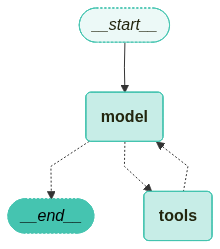

In [10]:
from langchain_opentutorial.graphs import visualize_graph
visualize_graph(main_agent, xray=True)

## 6. Execution Run
Let's test the entire multi-agent system with a query requiring multiple steps of delegation. Watch the console trace output to see the Main Agent call the subagents, and the subagents run their local mock tools!

In [11]:
# Test query
user_request = (
    "I want to plan a 3-day trip to Tokyo. My total budget limit is $1000. "
    "Recommend a hotel under $150/night, suggest ramen and sushi spots, "
    "and audit the expenses to see if they fit my budget."
)

print("=== STARTING TRAVEL CONCIERGE MULTI-AGENT SYSTEM ===\n")

# Invoke the main agent with a thread_id configuration for checkpointer
config = {"configurable": {"thread_id": "travel_plan_thread_1"}}
result = main_agent.invoke({"messages": [{"role": "user", "content": user_request}]}, config=config)

print("\n=== FINAL AGENT RESPONSE ===\n")
# Extract the final response from the messages
print(result["messages"][-1].content[0]['text'] if isinstance(result["messages"][-1].content, list) else result["messages"][-1].content)


=== STARTING TRAVEL CONCIERGE MULTI-AGENT SYSTEM ===


=== FINAL AGENT RESPONSE ===

I have successfully planned your 3-day trip to Tokyo. Here are the details for your itinerary and budget:

### **Hotel Recommendation**
I recommend **Hotel Sunroute Plaza Shinjuku**. It is a highly-rated, convenient business hotel located near Shinjuku Station, perfect for exploring the city.
*   **Cost:** $140/night (Total for 3 nights: $420 + tax = **$462**)

### **Dining Recommendations**
Tokyo offers incredible culinary experiences. Here are some top-tier spots to try:

*   **Ramen:**
    *   **Fuunji (Shinjuku):** Famous for rich, creamy *tsukemen*.
    *   **Ginza Kagari (Ginza):** Renowned for elegant, creamy chicken broth ramen.
    *   **Rokurinsha (Tokyo Station):** A legendary spot for robust, umami-packed dipping noodles.
*   **Sushi:**
    *   **Sushi No Midori (Shibuya):** Excellent quality at an accessible price point.
    *   **Sushi Dai (Toyosu Market):** The gold standard for fresh, m

In [12]:
# Test query
user_request = "okay that's great"


result = main_agent.invoke({"messages": [{"role": "user", "content": user_request}]}, config=config)

print("\n=== FINAL AGENT RESPONSE ===\n")
# Extract the final response from the messages
print(result["messages"][-1].content[0]['text'] if isinstance(result["messages"][-1].content, list) else result["messages"][-1].content)



=== FINAL AGENT RESPONSE ===

You're very welcome! I'm glad I could help you get your Tokyo trip organized. 

Since you have about $295 left in your budget, you might want to set that aside for:
*   **Transportation:** Consider getting a Suica or Pasmo card for easy travel on Tokyo's extensive train and subway network.
*   **Activities:** You could use some of the extra funds for entry fees to places like the Tokyo Skytree, teamLab Borderless, or a day trip to nearby areas like Kamakura or Hakone.

If you need help finding specific activities or have any other questions as your trip approaches, feel free to ask. Have an amazing time in Tokyo!


In [13]:
user_request = "Yes can you tell me the overall expense breakdown and if I'm within budget?, I forgot it"

result = main_agent.invoke({"messages": [{"role": "user", "content": user_request}]}, config=config)

print("\n=== FINAL AGENT RESPONSE ===\n")
# Extract the final response from the messages
print(result["messages"][-1].content[0]['text'] if isinstance(result["messages"][-1].content, list) else result["messages"][-1].content)



=== FINAL AGENT RESPONSE ===

Certainly! Here is the summary of your trip expenses and the final budget audit:

### **Trip Expense Breakdown**

| Category | Details | Estimated Cost |
| :--- | :--- | :--- |
| **Hotel** | 3 nights at Hotel Sunroute Plaza Shinjuku ($140/night + 10% tax) | $462.00 |
| **Food** | 3 days of meals (Ramen, Sushi, and Casual dining + 8% tax) | $243.00 |
| **Total Estimated Cost** | | **$705.00** |

### **Budget Audit Status**

*   **Your Total Budget Limit:** $1,000.00
*   **Total Estimated Expenses:** $705.00
*   **Remaining Funds:** $295.00

**Status: APPROVED**
You are well within your $1,000 budget, with **$295.00 remaining** for your transportation, souvenirs, or extra activities. You are all set!


## 7. TRUE STREAMING with .stream() Method
This cell implements ACTUAL streaming using the `.stream()` method instead of `.invoke()`. You will see:
- Tool calls happening in real-time
- Tool execution results appearing as they're computed
- Token-by-token LLM output streaming
- Intermediate agent thinking steps

In [14]:
import time
import json
import asyncio
import nest_asyncio
from rich.console import Console
from rich.panel import Panel
from langchain_core.messages import HumanMessage

# Apply nest_asyncio to allow asyncio.run() within the notebook's running event loop
nest_asyncio.apply()
console = Console()

async def true_stream_agent_async(agent, user_request: str, thread_id: str = "travel_plan_thread_2"):
    """
    TRUE REAL-TIME STREAMING using astream_events(version="v2").
    Captures and displays main agent and sub-agent tokens, tool calls, and results in real time.
    """
    console.print("\n" + "="*100, style="bold cyan")
    console.print("🚀 TRAVEL CONCIERGE MULTI-AGENT SYSTEM (TRUE REAL-TIME STREAMING)", style="bold magenta")
    console.print("="*100, style="bold cyan")
    console.print(f"\n📋 [bold yellow]User Request:[/bold yellow]")
    console.print(Panel(user_request, style="blue", expand=False))
    console.print("\n[bold magenta]🤖 Starting TRUE STREAMING Execution (using astream_events v2)...[/bold magenta]")
    console.print("[bold cyan]" + "─" * 100 + "[/bold cyan]\n")
    
    active_tool = None
    start_time = time.time()
    tool_count = 0
    
    try:
        config = {"configurable": {"thread_id": thread_id}}
        async for event in agent.astream_events(
            {"messages": [HumanMessage(content=user_request)]},
            config=config,
            version="v2"
        ):
            event_type = event.get("event")
            name = event.get("name")
            
            # Handle Tool Calls
            if event_type == "on_tool_start":
                active_tool = name
                tool_count += 1
                inputs = event.get("data", {}).get("input")
                console.print(f"\n\n[bold magenta]🔧 [Tool Start] {name}[/bold magenta]")
                console.print(f"  [dim]Input: {inputs}[/dim]\n")
                
            elif event_type == "on_tool_end":
                active_tool = None
                output = event.get("data", {}).get("output")
                if hasattr(output, 'content'):
                    output_str = str(output.content)
                elif isinstance(output, list) and len(output) > 0 and isinstance(output[0], dict) and 'text' in output[0]:
                    output_str = output[0]['text']
                else:
                    output_str = str(output)
                console.print(f"\n[bold green]✓ [Tool End] {name} Result:[/bold green]")
                console.print(Panel(output_str.strip(), style="green", expand=False))
                console.print()
                
            # Handle LLM Token Streaming
            elif event_type == "on_chat_model_stream":
                chunk = event.get("data", {}).get("chunk")
                content = chunk.content if hasattr(chunk, 'content') else str(chunk)
                
                # Color-code based on which agent is generating the response
                if active_tool == "Hotel_Finder_Agent":
                    console.print(content, style="green", end="")
                elif active_tool == "Culinary_Guide_Agent":
                    console.print(content, style="yellow", end="")
                elif active_tool == "Budget_Auditor_Agent":
                    console.print(content, style="red", end="")
                else:
                    # Main coordinator agent (Travel Concierge)
                    console.print(content, style="cyan", end="")
                    
        total_time = time.time() - start_time
        console.print("\n" + "="*100, style="bold cyan")
        console.print("✨ EXECUTION COMPLETE", justify="center", style="bold green")
        console.print("="*100, style="bold cyan")
        console.print(f"\n[bold yellow]📊 Stream Statistics:[/bold yellow]")
        console.print(f"  • Total execution time: {total_time:.2f}s")
        console.print(f"  • Tool calls executed: {tool_count}\n")
        
    except Exception as e:
        console.print(f"\n[bold red]❌ ERROR:[/bold red] {str(e)}")
        import traceback
        traceback.print_exc()

# Execute TRUE STREAMING
user_request = (
    "I want to plan a 3-day trip to Tokyo. My total budget limit is $1000. "
    "Recommend a hotel under $150/night, suggest ramen and sushi spots, "
    "and audit the expenses to see if they fit my budget."
)
asyncio.run(true_stream_agent_async(main_agent, user_request, thread_id="travel_plan_thread_2"))


====================================================================================================

🚀 TRAVEL CONCIERGE MULTI-AGENT SYSTEM (TRUE REAL-TIME STREAMING)

====================================================================================================

📋 User Request:

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ I want to plan a 3-day trip to Tokyo. My total budget limit is $1000. Recommend a hotel under $150/night,       │
│ suggest ramen and sushi spots, and audit the expenses to see if they fit my budget.                             │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

🤖 Starting TRUE STREAMING Execution (using astream_events v2)...

────────────────────────────────────────────────────────────────────────────────────────────────────

❌ ERROR: The SqliteSaver does not support async methods. Consider using AsyncSqliteSaver instead.
from langgraph.checkpoint.sqlite.aio import AsyncSqliteSaver
Note: AsyncSqliteSaver requires the aiosqlite package to use.
Install with:
`pip install aiosqlite`
See 
https://langchain-ai.github.io/langgraph/reference/checkpoints/#langgraph.checkpoint.sqlite.aio.AsyncSqliteSaverfor
more information.

Traceback (most recent call last):
  File "/var/folders/ry/0dp2gqbj4nv8q6qbdj7z67700000gn/T/ipykernel_61895/698906215.py", line 32, in true_stream_agent_async
    async for event in agent.astream_events(
  File "/Users/sachinmishra/Desktop/Agents_From_Scratch/.venv/lib/python3.12/site-packages/langchain_core/runnables/base.py", line 1607, in _astream_events_v1_v2
    async for event in event_stream:
  File "/Users/sachinmishra/Desktop/Agents_From_Scratch/.venv/lib/python3.12/site-packages/langchain_core/tracers/event_stream.py", line 1100, in _astream_events_implementation_v2
    await task
  File "/Users/sachinmishra/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/asyncio/futures.py", line 292, in __await__
    return self.result()  # May raise too.
           ^^^^^^^^^^^^^
  File "/Users/sachinmishra/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/asyncio/futures.py", line 202, in result
    raise self._exception.with_traceback(self._